# Laboratory Assignment 8: High-Performance Big Data Analytics Using R


## 1. Problem Statement
Analyse large-scale NYC yellow-taxi data in R and compare computational approaches:
base R, `apply`/`lapply`/`purrr::map` (functional), vectorized R, `data.table`, and sequential vs. parallel (`foreach` + `doParallel`) execution. Identify demand, fare, revenue, route and payment patterns, benchmark the approaches, and recommend the best one for large-scale analytics.

## 2. Dataset
* **Yellow Taxi Trip Records** (official TLC page: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page). Monthly parquet files are downloaded from the TLC CDN.
* **Taxi Zone Lookup Table** (maps LocationID → Borough, Zone).
* Default subset: **Jan–Mar 2023 (about 9 million raw rows)**. Change `MONTHS` below if Colab runs out of RAM (use `1:2`) or you want more data (`1:6`).

## 3. Setup: packages and configuration

In [1]:
# ---- Faster installs: use prebuilt Linux binaries from Posit Package Manager ----
os_codename <- tryCatch(system("lsb_release -cs", intern = TRUE), error = function(e) "jammy")
options(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
        paste(getRversion(), R.version["platform"], R.version["arch"], R.version["os"])))
options(repos = c(CRAN = paste0("https://packagemanager.posit.co/cran/__linux__/", os_codename, "/latest")))
options(timeout = 1800)

pkgs <- c("data.table", "ggplot2", "foreach", "doParallel", "microbenchmark",
          "bench", "purrr", "nanoparquet", "scales", "leaflet", "htmlwidgets")
to_install <- setdiff(pkgs, rownames(installed.packages()))
if (length(to_install)) install.packages(to_install)

suppressPackageStartupMessages({
  library(data.table); library(ggplot2); library(foreach); library(doParallel)
  library(microbenchmark); library(purrr); library(scales)
})

options(repr.plot.width = 11, repr.plot.height = 5.5)
options(datatable.print.nrows = 20, scipen = 999)
theme_set(theme_minimal(base_size = 13))

YEAR   <- 2023
MONTHS <- 1:3          # <- change to 1:2 if you run out of memory
SEED   <- 42
set.seed(SEED)
cat("data.table threads:", getDTthreads(), "| CPU cores:", parallel::detectCores(), "\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘proxy’, ‘e1071’, ‘wk’, ‘lazyeval’, ‘sp’, ‘terra’, ‘classInt’, ‘s2’, ‘units’, ‘iterators’, ‘profmem’, ‘crosstalk’, ‘leaflet.providers’, ‘png’, ‘raster’, ‘sf’




data.table threads: 1 | CPU cores: 2 


## 4. Task 1: Data Acquisition and Preparation
### 4.1 Import the data
Only the 11 required columns are read from the parquet files, which reduces memory from the start.

In [2]:
base_url <- "https://d37ci6vzurychx.cloudfront.net/trip-data/"
dir.create("data", showWarnings = FALSE)

keep_cols <- c("tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID",
               "passenger_count", "trip_distance", "payment_type", "fare_amount",
               "tip_amount", "tolls_amount", "total_amount")

read_month <- function(m) {
  f    <- sprintf("yellow_tripdata_%d-%02d.parquet", YEAR, m)
  path <- file.path("data", f)
  if (!file.exists(path)) download.file(paste0(base_url, f), path, mode = "wb", quiet = TRUE)
  as.data.table(nanoparquet::read_parquet(path, col_select = keep_cols))
}

t_load <- system.time(taxi <- rbindlist(lapply(MONTHS, read_month)))
cat("Loaded in", round(t_load["elapsed"], 1), "sec\n")

# Taxi zone lookup table
zones <- fread("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
print(head(zones))

Loaded in 8.4 sec
   LocationID       Borough                    Zone service_zone
        <int>        <char>                  <char>       <char>
1:          1           EWR          Newark Airport          EWR
2:          2        Queens             Jamaica Bay    Boro Zone
3:          3         Bronx Allerton/Pelham Gardens    Boro Zone
4:          4     Manhattan           Alphabet City  Yellow Zone
5:          5 Staten Island           Arden Heights    Boro Zone
6:          6 Staten Island Arrochar/Fort Wadsworth    Boro Zone


### 4.2 Inspect structure, dimensions, types and summary statistics

In [3]:
cat("Dimensions:", nrow(taxi), "rows x", ncol(taxi), "columns\n")
cat("Memory     :", format(object.size(taxi), units = "MB"), "\n\n")
str(taxi)
print(summary(taxi))
cat("\nMissing values per column:\n"); print(colSums(is.na(taxi)))
cat("\nExact duplicate rows:", sum(duplicated(taxi)), "\n")

Dimensions: 9384487 rows x 11 columns
Memory     : 787.6 Mb 

Classes ‘data.table’ and 'data.frame':	9384487 obs. of  11 variables:
 $ tpep_pickup_datetime : POSIXct, format: "2023-01-01 00:32:10" "2023-01-01 00:55:08" ...
 $ tpep_dropoff_datetime: POSIXct, format: "2023-01-01 00:40:36" "2023-01-01 01:01:27" ...
 $ PULocationID         : num  161 43 48 138 107 161 239 142 164 141 ...
 $ DOLocationID         : num  141 237 238 7 79 137 143 200 236 107 ...
 $ passenger_count      : num  1 1 1 0 1 1 1 1 1 1 ...
 $ trip_distance        : num  0.97 1.1 2.51 1.9 1.43 1.84 1.66 11.7 2.95 3.01 ...
 $ payment_type         : num  2 1 1 1 1 1 1 1 1 2 ...
 $ fare_amount          : num  9.3 7.9 14.9 12.1 11.4 12.8 12.1 45.7 17.7 14.9 ...
 $ tip_amount           : num  0 4 15 0 3.28 ...
 $ tolls_amount         : num  0 0 0 0 0 0 0 3 0 0 ...
 $ total_amount         : num  14.3 16.9 34.9 20.9 19.7 ...
 - attr(*, ".internal.selfref")=<pointer: 0x58c6caafc3f0> 
 tpep_pickup_datetime          tpep_dropof

### 4.3 Clean: duplicates, missing, inconsistent and invalid records
Rules applied: remove duplicates and NA passenger/payment values; keep only positive distance/fare/total; passengers 1–6; trip duration 1–180 min; average speed ≤ 80 mph; payment types 1–4; valid zone IDs; pickup timestamps inside the selected months.

In [4]:
n_raw <- nrow(taxi)

taxi <- unique(taxi)
n_dedup <- nrow(taxi)

taxi <- taxi[!is.na(passenger_count) & !is.na(payment_type)]
n_nona <- nrow(taxi)

taxi[, trip_minutes := as.numeric(difftime(tpep_dropoff_datetime, tpep_pickup_datetime, units = "mins"))]
taxi[, avg_mph := trip_distance / (trip_minutes / 60)]

taxi <- taxi[
  year(tpep_pickup_datetime) == YEAR & month(tpep_pickup_datetime) %in% MONTHS &
  trip_distance > 0 & trip_distance <= 100 &
  fare_amount > 0 & fare_amount <= 500 &
  total_amount > 0 & total_amount <= 1000 &
  tip_amount >= 0 & tolls_amount >= 0 &
  passenger_count >= 1 & passenger_count <= 6 &
  trip_minutes >= 1 & trip_minutes <= 180 &
  avg_mph <= 80 &
  payment_type %in% 1:4 &
  PULocationID %between% c(1, 265) & DOLocationID %between% c(1, 265)
]

cleaning_log <- data.table(
  step = c("Raw rows", "After removing duplicates", "After removing NA", "After validity filters"),
  rows = c(n_raw, n_dedup, n_nona, nrow(taxi)))
cleaning_log[, removed := shift(rows, 1) - rows]
print(cleaning_log)
cat(sprintf("\nRetained %.1f%% of raw records\n", 100 * nrow(taxi) / n_raw))

                        step    rows removed
                      <char>   <int>   <int>
1:                  Raw rows 9384487      NA
2: After removing duplicates 9384487       0
3:         After removing NA 9148308  236179
4:    After validity filters 8771766  376542

Retained 93.5% of raw records


### 4.4 Data types, temporal features, and dropping unneeded columns

In [5]:
mem_before <- object.size(taxi)

taxi[, `:=`(
  passenger_count = as.integer(passenger_count),
  PULocationID    = as.integer(PULocationID),
  DOLocationID    = as.integer(DOLocationID),
  payment_type    = factor(payment_type, levels = 1:4,
                           labels = c("Credit card", "Cash", "No charge", "Dispute")),
  hour  = hour(tpep_pickup_datetime),
  day   = mday(tpep_pickup_datetime),
  dow   = factor(wday(tpep_pickup_datetime), levels = 1:7,
                 labels = c("Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat")),
  month = month(tpep_pickup_datetime)
)]

taxi[, period := cut(hour, breaks = c(-1, 5, 11, 17, 21, 23),
                     labels = c("Late night (0-5)", "Morning (6-11)", "Afternoon (12-17)",
                                "Evening (18-21)", "Night (22-23)"))]
taxi[, is_weekend := dow %in% c("Sat", "Sun")]

# remove columns no longer needed (reduces memory)
taxi[, c("tpep_pickup_datetime", "tpep_dropoff_datetime") := NULL]
invisible(gc())
cat("Memory before:", format(mem_before, units = "MB"), "-> after:", format(object.size(taxi), units = "MB"), "\n")
str(taxi)

Memory before: 870 Mb -> after: 803.1 Mb 
Classes ‘data.table’ and 'data.frame':	8771766 obs. of  17 variables:
 $ PULocationID   : int  161 43 48 107 161 239 142 164 141 234 ...
 $ DOLocationID   : int  141 237 238 79 137 143 200 236 107 68 ...
 $ passenger_count: int  1 1 1 1 1 1 1 1 1 1 ...
 $ trip_distance  : num  0.97 1.1 2.51 1.43 1.84 1.66 11.7 2.95 3.01 1.8 ...
 $ payment_type   : Factor w/ 4 levels "Credit card",..: 2 1 1 1 1 1 1 1 2 1 ...
 $ fare_amount    : num  9.3 7.9 14.9 11.4 12.8 12.1 45.7 17.7 14.9 11.4 ...
 $ tip_amount     : num  0 4 15 3.28 10 ...
 $ tolls_amount   : num  0 0 0 0 0 0 3 0 0 0 ...
 $ total_amount   : num  14.3 16.9 34.9 19.7 27.8 ...
 $ trip_minutes   : num  8.43 6.32 12.75 10.83 12.3 ...
 $ avg_mph        : num  6.9 10.45 11.81 7.92 8.98 ...
 $ hour           : int  0 0 0 0 0 0 0 0 0 0 ...
 $ day            : int  1 1 1 1 1 1 1 1 1 1 ...
 $ dow            : Factor w/ 7 levels "Sun","Mon","Tue",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ month          : int  1 1 

### 4.5 Join with the Taxi Zone Lookup Table (pickup and drop-off) using data.table

In [6]:
zones[, `:=`(Borough = factor(Borough), Zone = factor(Zone))]

# update-by-reference joins (no copy of the big table)
taxi[zones, on = .(PULocationID = LocationID), `:=`(PU_Borough = i.Borough, PU_Zone = i.Zone)]
taxi[zones, on = .(DOLocationID = LocationID), `:=`(DO_Borough = i.Borough, DO_Zone = i.Zone)]

cat("Unmatched pickup zones :", sum(is.na(taxi$PU_Zone)), "\n")
cat("Unmatched drop-off zones:", sum(is.na(taxi$DO_Zone)), "\n")
print(head(taxi))
cat("Final cleaned dataset:", format(nrow(taxi), big.mark = ","), "rows\n")

Unmatched pickup zones : 0 
Unmatched drop-off zones: 0 
   PULocationID DOLocationID passenger_count trip_distance payment_type
          <int>        <int>           <int>         <num>       <fctr>
1:          161          141               1          0.97         Cash
2:           43          237               1          1.10  Credit card
3:           48          238               1          2.51  Credit card
4:          107           79               1          1.43  Credit card
5:          161          137               1          1.84  Credit card
6:          239          143               1          1.66  Credit card
   fare_amount tip_amount tolls_amount total_amount trip_minutes   avg_mph
         <num>      <num>        <num>        <num>        <num>     <num>
1:         9.3       0.00            0        14.30     8.433333  6.901186
2:         7.9       4.00            0        16.90     6.316667 10.448549
3:        14.9      15.00            0        34.90    12.750000 11

## 5. Task 2: Transportation Data Analytics (data.table)

In [7]:
# 1-3. Demand by hour / day of week / month, with avg fare and revenue (items 4)
by_hour  <- taxi[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), by = hour][order(hour)]
by_dow   <- taxi[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), by = dow][order(dow)]
by_month <- taxi[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), by = month][order(month)]
by_period<- taxi[, .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount)), by = period][order(period)]

cat("--- Trips by hour ---\n");        print(by_hour)
cat("\n--- Trips by day of week ---\n"); print(by_dow)
cat("\n--- Monthly ---\n");             print(by_month)
cat("\n--- By time of day ---\n");      print(by_period)

--- Trips by hour ---
     hour  trips avg_fare  revenue
    <int>  <int>    <num>    <num>
 1:     0 237093 19.63778  6803204
 2:     1 159184 17.77006  4178585
 3:     2 103581 16.69137  2570352
 4:     3  70435 17.74685  1836206
 5:     4  44785 22.83896  1453084
---                               
20:    19 564121 17.57074 15544715
21:    20 493263 18.02161 13384852
22:    21 485931 18.41818 13414392
23:    22 446348 19.27613 12728886
24:    23 346633 20.31980 10322177

--- Trips by day of week ---
      dow   trips avg_fare  revenue
   <fctr>   <int>    <num>    <num>
1:    Sun 1102386 19.80552 31467521
2:    Mon 1067777 19.54077 30757939
3:    Tue 1249582 18.39571 34284906
4:    Wed 1335112 18.47483 36815447
5:    Thu 1400174 18.73192 39054533
6:    Fri 1369922 18.47876 37825120
7:    Sat 1246813 17.67204 32048220

--- Monthly ---
   month   trips avg_fare  revenue
   <int>   <int>    <num>    <num>
1:     1 2872758 18.50599 78495083
2:     2 2721764 18.40660 74210839
3:     3 317

In [8]:
# 5-6. Most frequent routes and highest-revenue routes
routes <- taxi[, .(trips = .N, revenue = sum(total_amount),
                   avg_fare = mean(fare_amount), avg_dist = mean(trip_distance)),
               by = .(PU_Zone, DO_Zone)]
routes[, route := paste(PU_Zone, "->", DO_Zone)]

top_routes_trips <- routes[order(-trips)][1:15]
top_routes_rev   <- routes[order(-revenue)][1:15]
cat("--- Top 15 routes by number of trips ---\n");  print(top_routes_trips[, .(route, trips, avg_fare)])
cat("\n--- Top 15 routes by revenue ---\n");        print(top_routes_rev[, .(route, revenue, trips)])

top_pu <- taxi[, .(trips = .N, revenue = sum(total_amount)), by = PU_Zone][order(-trips)][1:15]
top_do <- taxi[, .(trips = .N, revenue = sum(total_amount)), by = DO_Zone][order(-trips)][1:15]

--- Top 15 routes by number of trips ---
                                                        route trips  avg_fare
                                                       <char> <int>     <num>
 1:            Upper East Side South -> Upper East Side North 61242  8.643514
 2:                                                N/A -> N/A 54945 19.075747
 3:            Upper East Side North -> Upper East Side South 52079  9.284823
 4:            Upper East Side North -> Upper East Side North 39481  6.712960
 5:            Upper East Side South -> Upper East Side South 38506  7.147515
 6:                   Midtown Center -> Upper East Side South 27372  9.775037
 7:                   Upper East Side South -> Midtown Center 26711  9.819277
 8:                   Midtown Center -> Upper East Side North 24896 13.659572
 9:              Lincoln Square East -> Upper West Side South 23532  8.020636
10:            Upper West Side South -> Upper West Side North 23205  7.176422
11:                  Le

In [9]:
# 7. Trip distance vs fare
cat("Pearson correlation (distance, fare):", round(cor(taxi$trip_distance, taxi$fare_amount), 4), "\n")
fit <- lm(fare_amount ~ trip_distance, data = taxi[sample(.N, 500000)])
print(round(coef(fit), 3))
cat("R-squared:", round(summary(fit)$r.squared, 4), "\n\n")

dist_bins <- taxi[, .(trips = .N, avg_fare = mean(fare_amount),
                      fare_per_mile = sum(fare_amount) / sum(trip_distance)),
                  by = .(dist_bin = cut(trip_distance, c(0, 1, 2, 3, 5, 10, 20, Inf)))][order(dist_bin)]
print(dist_bins)

Pearson correlation (distance, fare): 0.9634 
  (Intercept) trip_distance 
        6.057         3.699 
R-squared: 0.9285 

   dist_bin   trips avg_fare fare_per_mile
     <fctr>   <int>    <num>         <num>
1:    (0,1] 1944962  7.36192     10.259797
2:    (1,2] 2937922 11.32190      7.703120
3:    (2,3] 1421576 16.02511      6.541263
4:    (3,5] 1009909 21.80653      5.738088
5:   (5,10]  737868 33.86831      4.662556
6:  (10,20]  629053 61.40248      4.099569
7: (20,Inf]   90476 87.61174      3.718747


In [10]:
# 8. Payment methods across boroughs
pay_borough <- taxi[, .N, by = .(PU_Borough, payment_type)][, share := N / sum(N), by = PU_Borough]
print(dcast(pay_borough, PU_Borough ~ payment_type, value.var = "share"))

# 9. Additional patterns
cat("\n--- Tip % of fare by payment type (cash tips are not recorded) ---\n")
print(taxi[, .(avg_tip_pct = round(100 * sum(tip_amount) / sum(fare_amount), 2)), by = payment_type])

airports <- c("JFK Airport", "LaGuardia Airport", "Newark Airport")
air <- taxi[PU_Zone %in% airports | DO_Zone %in% airports,
            .(trips = .N, avg_fare = mean(fare_amount), revenue = sum(total_amount))]
cat("\n--- Airport trips ---\n"); print(air)
cat(sprintf("Airport trips = %.1f%% of trips but %.1f%% of revenue\n",
            100 * air$trips / nrow(taxi), 100 * air$revenue / sum(taxi$total_amount)))

cat("\n--- Median speed (mph) by hour ---\n")
speed_hour <- taxi[, .(median_mph = median(avg_mph)), by = hour][order(hour)]
print(speed_hour)

cat("\n--- Weekday vs weekend ---\n")
print(taxi[, .(trips = .N, avg_fare = mean(fare_amount), avg_dist = mean(trip_distance)), by = is_weekend])

Key: <PU_Borough>
      PU_Borough Credit card       Cash   No charge     Dispute
          <fctr>       <num>      <num>       <num>       <num>
1:         Bronx   0.8275294 0.16093138 0.004533278 0.007005976
2:      Brooklyn   0.8026521 0.18386023 0.005747996 0.007739626
3:           EWR   0.7014925 0.22388060 0.059701493 0.014925373
4:     Manhattan   0.8270249 0.16490991 0.002890473 0.005174692
5:           N/A   0.6864407 0.26271186 0.021186441 0.029661017
6:        Queens   0.7724853 0.21598822 0.004444166 0.007082341
7: Staten Island   0.9522901 0.04389313 0.001908397 0.001908397
8:       Unknown   0.8154200 0.17537131 0.001891636 0.007317099

--- Tip % of fare by payment type (cash tips are not recorded) ---
   payment_type avg_tip_pct
         <fctr>       <num>
1:         Cash        0.00
2:  Credit card       22.54
3:      Dispute        0.13
4:    No charge        0.03

--- Airport trips ---
    trips avg_fare  revenue
    <int>    <num>    <num>
1: 895190 55.66951 68002045

## 6. Task 3: Functional vs Vectorized vs data.table
Two experiments:
* **Experiment A (group-wise aggregation, full data):** average fare by hour using base R, `apply`, `lapply`, `purrr::map`, vectorized `rowsum`, and `data.table`.
* **Experiment B (row-wise computation, 100,000-row sample):** tip percentage per trip using `apply`, `lapply`, `purrr::map2_dbl`, vectorized, and `data.table`. Row-wise functional code is far too slow for millions of rows, so a sample is used for fairness.

In [11]:
# helper: time (microbenchmark) + memory (bench::mark) for a named list of functions
compare <- function(fns, times = 5, mem_iters = 3) {
  exprs <- lapply(names(fns), function(n) bquote(fns[[.(n)]]()))
  names(exprs) <- names(fns)
  mb <- microbenchmark::microbenchmark(list = exprs, times = times)
  s  <- summary(mb, unit = "ms")
  bm <- bench::mark(exprs = exprs, iterations = mem_iters, check = FALSE,
                    filter_gc = FALSE, env = environment())
  out <- data.table(approach = as.character(s$expr),
                    median_ms = s$median,
                    mem_MB = as.numeric(bm$mem_alloc)[match(as.character(s$expr), names(fns))] / 1e6)
  out[, rel_to_fastest := round(median_ms / min(median_ms), 1)]
  out[order(median_ms)]
}

In [12]:
# ---------- Experiment A: mean fare per hour (full data) ----------
df <- as.data.frame(taxi[, .(hour, fare_amount)])

fnsA <- list(
  base_tapply     = function() tapply(df$fare_amount, df$hour, mean),
  base_aggregate  = function() aggregate(fare_amount ~ hour, data = df, FUN = mean),
  apply_loop      = function() apply(matrix(0:23), 1, function(h) mean(df$fare_amount[df$hour == h])),
  lapply_split    = function() lapply(split(df$fare_amount, df$hour), mean),
  purrr_map_dbl   = function() map_dbl(split(df$fare_amount, df$hour), mean),
  vectorized_rowsum = function() rowsum(df$fare_amount, df$hour) / tabulate(df$hour + 1L, 24L),
  data.table      = function() taxi[, .(avg_fare = mean(fare_amount)), by = hour]
)

# correctness check: all approaches should give the same answer
ref <- as.numeric(fnsA$base_tapply())
stopifnot(isTRUE(all.equal(ref, as.numeric(fnsA$vectorized_rowsum()))),
          isTRUE(all.equal(ref, taxi[, mean(fare_amount), by = hour][order(hour)]$V1)))

res_A <- compare(fnsA, times = 5)
cat("Experiment A: average fare by hour on", format(nrow(df), big.mark = ","), "rows\n")
print(res_A)

Experiment A: average fare by hour on 8,771,766 rows
            approach median_ms    mem_MB rel_to_fastest
              <char>     <num>     <num>          <num>
1: vectorized_rowsum  425.0137  239.4797            1.0
2:        data.table  435.5097  258.2480            1.0
3:     purrr_map_dbl  484.6434  309.6557            1.1
4:      lapply_split  515.0605  309.6557            1.2
5:       base_tapply  710.7560  379.8314            1.7
6:        apply_loop 1266.4844 1789.4456            3.0
7:    base_aggregate 6291.7167 2103.5384           14.8


In [13]:
# ---------- Experiment B: row-wise tip % on a 100k sample ----------
samp <- taxi[sample(.N, 1e5), .(fare_amount, tip_amount, tolls_amount, trip_distance)]
sdf  <- as.data.frame(samp)
smat <- as.matrix(samp)

fnsB <- list(
  apply_rows   = function() apply(smat, 1, function(r) r[["tip_amount"]] / r[["fare_amount"]] * 100),
  lapply_index = function() unlist(lapply(seq_len(nrow(sdf)), function(i) sdf$tip_amount[i] / sdf$fare_amount[i] * 100)),
  purrr_map2   = function() map2_dbl(sdf$tip_amount, sdf$fare_amount, ~ .x / .y * 100),
  vectorized   = function() sdf$tip_amount / sdf$fare_amount * 100,
  data.table   = function() samp[, tip_amount / fare_amount * 100]
)
stopifnot(isTRUE(all.equal(as.numeric(fnsB$apply_rows()), as.numeric(fnsB$vectorized()))))

res_B <- compare(fnsB, times = 5)
cat("Experiment B: row-wise tip % on", format(nrow(sdf), big.mark = ","), "rows\n")
print(res_B)

Experiment B: row-wise tip % on 100,000 rows
       approach  median_ms   mem_MB rel_to_fastest
         <char>      <num>    <num>          <num>
1:   vectorized   0.473947 0.800048            1.0
2:   data.table   1.785692 0.833416            3.8
3:   purrr_map2 249.651772 0.800264          526.8
4: lapply_index 419.160867 1.600096          884.4
5:   apply_rows 420.671615 5.600240          887.6


## 7. Task 4: Parallel Computing (month-wise partitions)
**Computationally intensive operation:** for every month, estimate the *fare-per-mile slope* with a **bootstrap** (repeated resampling of 200,000 trips, fitting `lm.fit` each time).
* **Sequential:** `foreach(...) %do%`
* **Parallel:** `foreach(...) %dopar%` with `doParallel`
* Experiment 1 uses **one task per month** (coarse). Experiment 2 splits each month into **4 chunks** (fine-grained) so more cores can be used.

In [14]:
parts <- split(taxi[, .(trip_distance, fare_amount, month)], by = "month")  # month-wise subsets
cat("Partitions:", paste(names(parts), sapply(parts, nrow), sep = ": ", collapse = " | "), "\n")

boot_slopes <- function(d, B = 100, n = 200000, seed = 1) {
  set.seed(seed)
  X <- cbind(1, d$trip_distance); y <- d$fare_amount
  vapply(seq_len(B), function(b) {
    idx <- sample.int(length(y), n, replace = TRUE)
    lm.fit(X[idx, , drop = FALSE], y[idx])$coefficients[2]
  }, numeric(1))
}

summarise_month <- function(m, s) data.table(month = m, slope_mean = mean(s), slope_sd = sd(s),
                                             ci_low = unname(quantile(s, .025)), ci_high = unname(quantile(s, .975)))

# ---- Experiment 1: one task per month ----
run_seq <- function() foreach(m = names(parts), .combine = rbind) %do%
  summarise_month(m, boot_slopes(parts[[m]], B = 100, seed = as.integer(m)))

run_par <- function(k) {
  registerDoParallel(cores = k); on.exit(stopImplicitCluster())
  foreach(m = names(parts), .combine = rbind, .packages = "data.table") %dopar%
    summarise_month(m, boot_slopes(parts[[m]], B = 100, seed = as.integer(m)))
}

n_cores <- max(1L, parallel::detectCores())
cat("Using up to", n_cores, "cores\n")

t_seq <- system.time(res_seq <- run_seq())["elapsed"]
t_par <- system.time(res_par <- run_par(n_cores))["elapsed"]
stopifnot(isTRUE(all.equal(res_seq, res_par)))   # identical results

exp1 <- data.table(experiment = "1: month-wise (coarse)", tasks = length(parts), cores = n_cores,
                   seq_sec = as.numeric(t_seq), par_sec = as.numeric(t_par))
exp1[, `:=`(speedup = seq_sec / par_sec, efficiency = (seq_sec / par_sec) / cores)]
print(res_par)
print(exp1)

Partitions: 1: 2872758 | 2: 2721764 | 3: 3177244 
Using up to 2 cores
    month slope_mean    slope_sd   ci_low  ci_high
   <char>      <num>       <num>    <num>    <num>
1:      1   3.691077 0.010598558 3.670639 3.711492
2:      2   3.712868 0.011607644 3.689408 3.735991
3:      3   3.715848 0.008386219 3.697484 3.728918
               experiment tasks cores seq_sec par_sec  speedup efficiency
                   <char> <int> <int>   <num>   <num>    <num>      <num>
1: 1: month-wise (coarse)     3     2  13.872  12.531 1.107015  0.5535073


In [15]:
# ---- Experiment 2: month x 4 chunks (fine-grained tasks) ----
task_grid <- CJ(month = names(parts), chunk = 1:4)

seq_fine <- function() {
  r <- foreach(i = seq_len(nrow(task_grid)), .combine = rbind) %do% {
    m <- task_grid$month[i]
    data.table(month = m, slope = boot_slopes(parts[[m]], B = 25, seed = i))
  }
  r[, summarise_month(month[1], slope), by = month][, -1]
}
par_fine <- function(k) {
  registerDoParallel(cores = k); on.exit(stopImplicitCluster())
  r <- foreach(i = seq_len(nrow(task_grid)), .combine = rbind, .packages = "data.table") %dopar% {
    m <- task_grid$month[i]
    data.table(month = m, slope = boot_slopes(parts[[m]], B = 25, seed = i))
  }
  r[, summarise_month(month[1], slope), by = month][, -1]
}

t_seq2 <- system.time(r2s <- seq_fine())["elapsed"]
t_par2 <- system.time(r2p <- par_fine(n_cores))["elapsed"]
exp2 <- data.table(experiment = "2: month x chunk (fine)", tasks = nrow(task_grid), cores = n_cores,
                   seq_sec = as.numeric(t_seq2), par_sec = as.numeric(t_par2))
exp2[, `:=`(speedup = seq_sec / par_sec, efficiency = (seq_sec / par_sec) / cores)]

# ---- Experiment 3: scalability over number of cores ----
ks <- sort(unique(c(1L, 2L, n_cores)))
ks <- ks[ks <= n_cores]
core_scaling <- rbindlist(lapply(ks, function(k) {
  tt <- as.numeric(system.time(par_fine(k))["elapsed"])
  data.table(cores = k, par_sec = tt, speedup = as.numeric(t_seq2) / tt)
}))

parallel_tbl <- rbind(exp1, exp2)
cat("=== Sequential vs Parallel ===\n"); print(parallel_tbl)
cat("\n=== Scaling with cores (fine-grained tasks) ===\n"); print(core_scaling)

=== Sequential vs Parallel ===
                experiment tasks cores seq_sec par_sec  speedup efficiency
                    <char> <int> <int>   <num>   <num>    <num>      <num>
1:  1: month-wise (coarse)     3     2  13.872  12.531 1.107015  0.5535073
2: 2: month x chunk (fine)    12     2  13.270  11.316 1.172676  0.5863379

=== Scaling with cores (fine-grained tasks) ===
   cores par_sec  speedup
   <int>   <num>    <num>
1:     1  12.906 1.028204
2:     2  11.008 1.205487


## 8. Task 5: Performance Benchmarking: Combined Comparison
Adds a **join** benchmark (base `merge` / `match` vs data.table join on 1 M rows) and builds the final execution-time comparison table.

In [16]:
js <- taxi[sample(.N, 1e6), .(PULocationID, fare_amount)]
js_df <- as.data.frame(js)
zones_df <- as.data.frame(zones[, .(LocationID, Borough)])
zones_dt <- zones[, .(LocationID, Borough)]

fnsJ <- list(
  base_merge = function() merge(js_df, zones_df, by.x = "PULocationID", by.y = "LocationID", all.x = TRUE),
  base_match = function() zones_df$Borough[match(js_df$PULocationID, zones_df$LocationID)],
  data.table_join = function() zones_dt[js, on = .(LocationID = PULocationID)]
)
res_J <- compare(fnsJ, times = 5)
print(res_J)

          approach  median_ms    mem_MB rel_to_fastest
            <char>      <num>     <num>          <num>
1:      base_match   15.62170  12.00540            1.0
2: data.table_join   84.24204  36.10914            5.4
3:      base_merge 2644.18821 227.50810          169.3


In [17]:
# Final comparison table
all_results <- rbindlist(list(
  `A: group mean by hour (9M-row scale)` = res_A,
  `B: row-wise tip % (100k rows)`        = res_B,
  `C: join with zones (1M rows)`         = res_J),
  idcol = "task")

par_rows <- rbind(
  data.table(task = "D: bootstrap, month-wise (coarse)", approach = c("sequential (foreach %do%)", "parallel (foreach %dopar%)"),
             median_ms = 1000 * c(exp1$seq_sec, exp1$par_sec)),
  data.table(task = "E: bootstrap, month x chunk (fine)", approach = c("sequential (foreach %do%)", "parallel (foreach %dopar%)"),
             median_ms = 1000 * c(exp2$seq_sec, exp2$par_sec)))
par_rows[, rel_to_fastest := round(median_ms / min(median_ms), 2), by = task]

all_results <- rbind(all_results, par_rows, fill = TRUE)
all_results[, median_ms := round(median_ms, 2)]
all_results[, mem_MB := round(mem_MB, 1)]
print(all_results, nrows = 100)

# measured speedups of data.table over other approaches (Exp. A)
cat("\nExperiment A: slowdown relative to data.table\n")
print(res_A[, .(approach, median_ms, times_slower_than_dt = round(median_ms / median_ms[approach == "data.table"], 1))])

                                    task                   approach median_ms
                                  <char>                     <char>     <num>
 1: A: group mean by hour (9M-row scale)          vectorized_rowsum    425.01
 2: A: group mean by hour (9M-row scale)                 data.table    435.51
 3: A: group mean by hour (9M-row scale)              purrr_map_dbl    484.64
 4: A: group mean by hour (9M-row scale)               lapply_split    515.06
 5: A: group mean by hour (9M-row scale)                base_tapply    710.76
 6: A: group mean by hour (9M-row scale)                 apply_loop   1266.48
 7: A: group mean by hour (9M-row scale)             base_aggregate   6291.72
 8:        B: row-wise tip % (100k rows)                 vectorized      0.47
 9:        B: row-wise tip % (100k rows)                 data.table      1.79
10:        B: row-wise tip % (100k rows)                 purrr_map2    249.65
11:        B: row-wise tip % (100k rows)               lapply_in

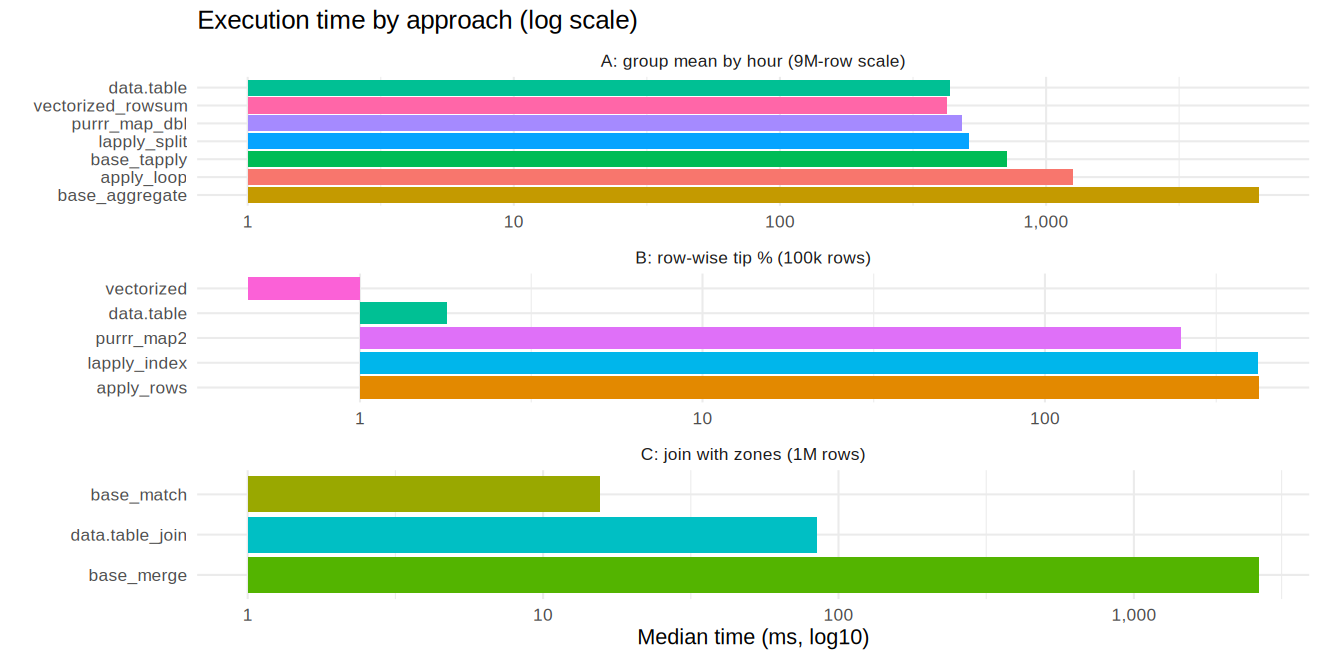

In [18]:
# Benchmark visualisation
ggplot(all_results[!grepl("^D|^E", task)],
       aes(reorder(approach, -median_ms), median_ms, fill = approach)) +
  geom_col(show.legend = FALSE) + coord_flip() + facet_wrap(~ task, scales = "free", ncol = 1) +
  scale_y_log10(labels = comma) +
  labs(title = "Execution time by approach (log scale)", x = NULL, y = "Median time (ms, log10)")

## 9. Task 6: Data Visualization (ggplot2)

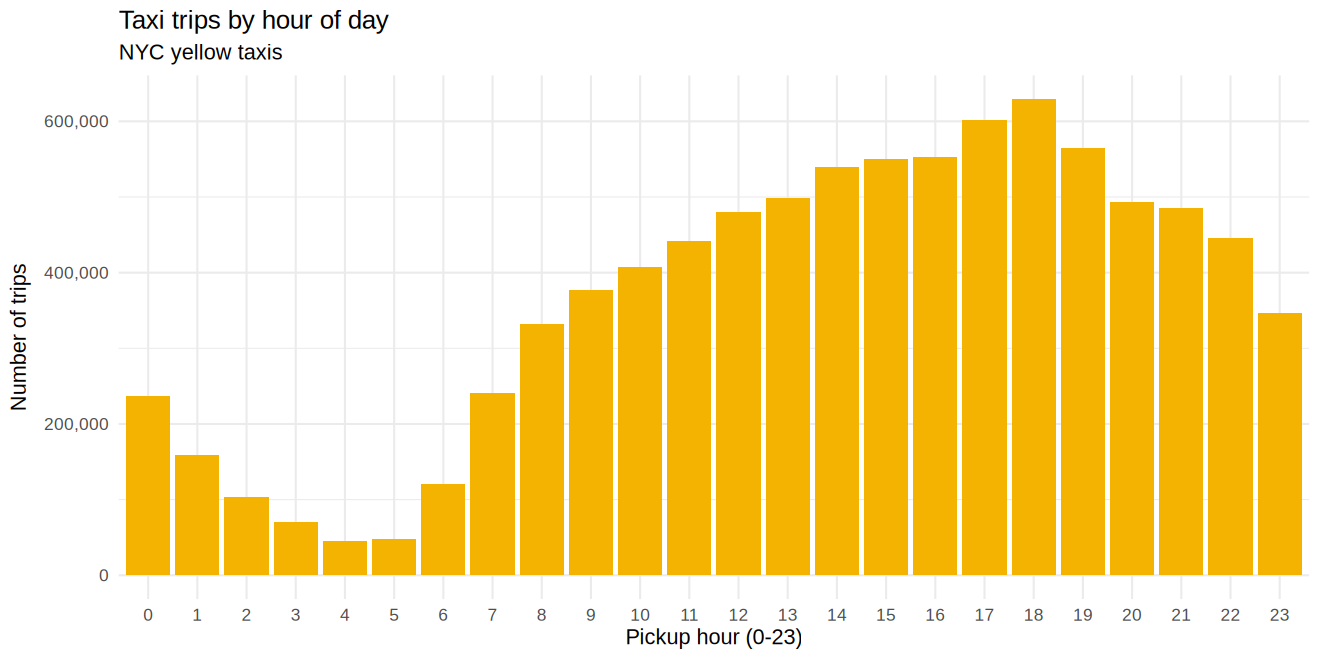

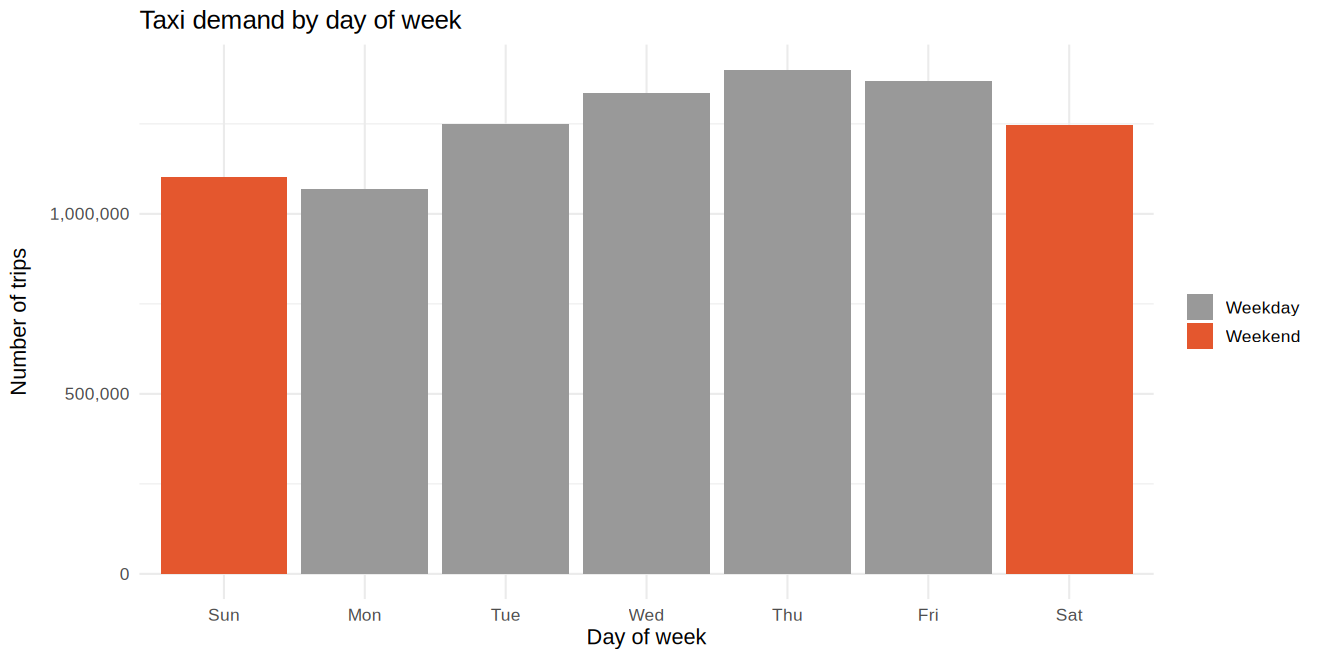

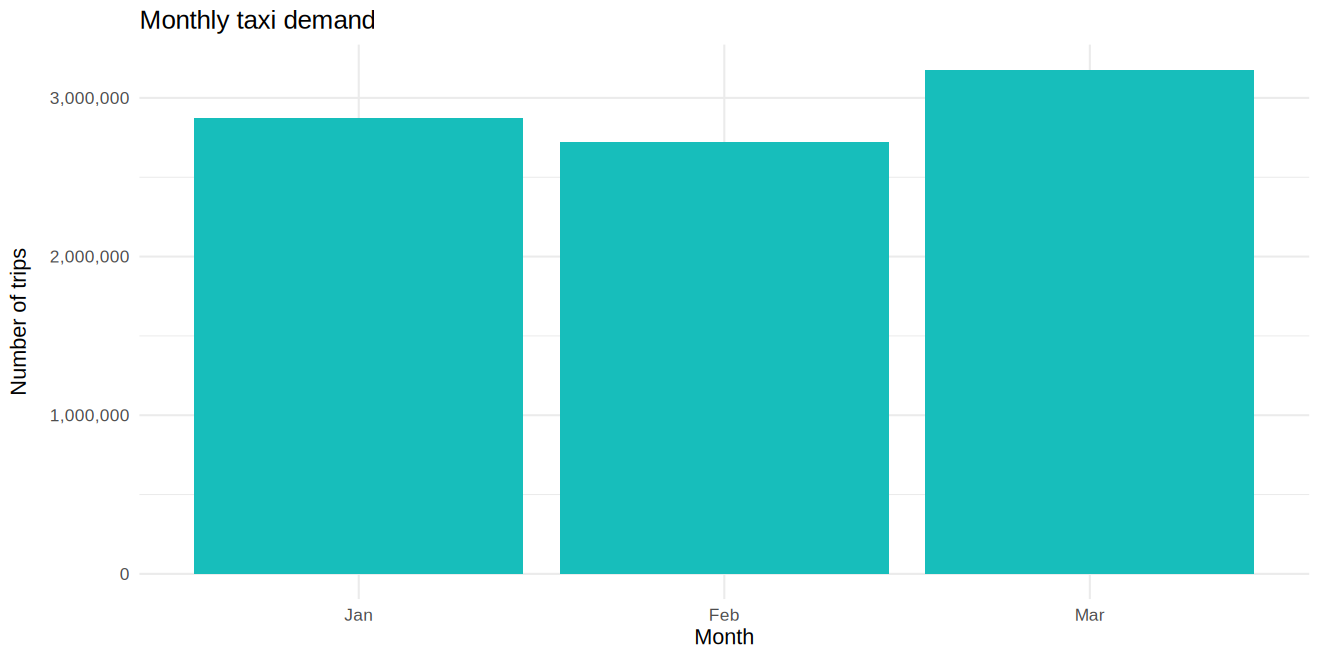

In [19]:
mon_lab <- function(m) factor(m, levels = MONTHS, labels = month.abb[MONTHS])

# 1. Trips by hour
ggplot(by_hour, aes(factor(hour), trips)) + geom_col(fill = "#F5B301") +
  scale_y_continuous(labels = comma) +
  labs(title = "Taxi trips by hour of day", subtitle = "NYC yellow taxis",
       x = "Pickup hour (0-23)", y = "Number of trips")

# 2. Demand by day of week
ggplot(by_dow, aes(dow, trips, fill = dow %in% c("Sat", "Sun"))) + geom_col() +
  scale_fill_manual(values = c("grey60", "#E4572E"), labels = c("Weekday", "Weekend"), name = NULL) +
  scale_y_continuous(labels = comma) +
  labs(title = "Taxi demand by day of week", x = "Day of week", y = "Number of trips")

# 3. Monthly demand
ggplot(by_month, aes(mon_lab(month), trips)) + geom_col(fill = "#17BEBB") +
  scale_y_continuous(labels = comma) +
  labs(title = "Monthly taxi demand", x = "Month", y = "Number of trips")

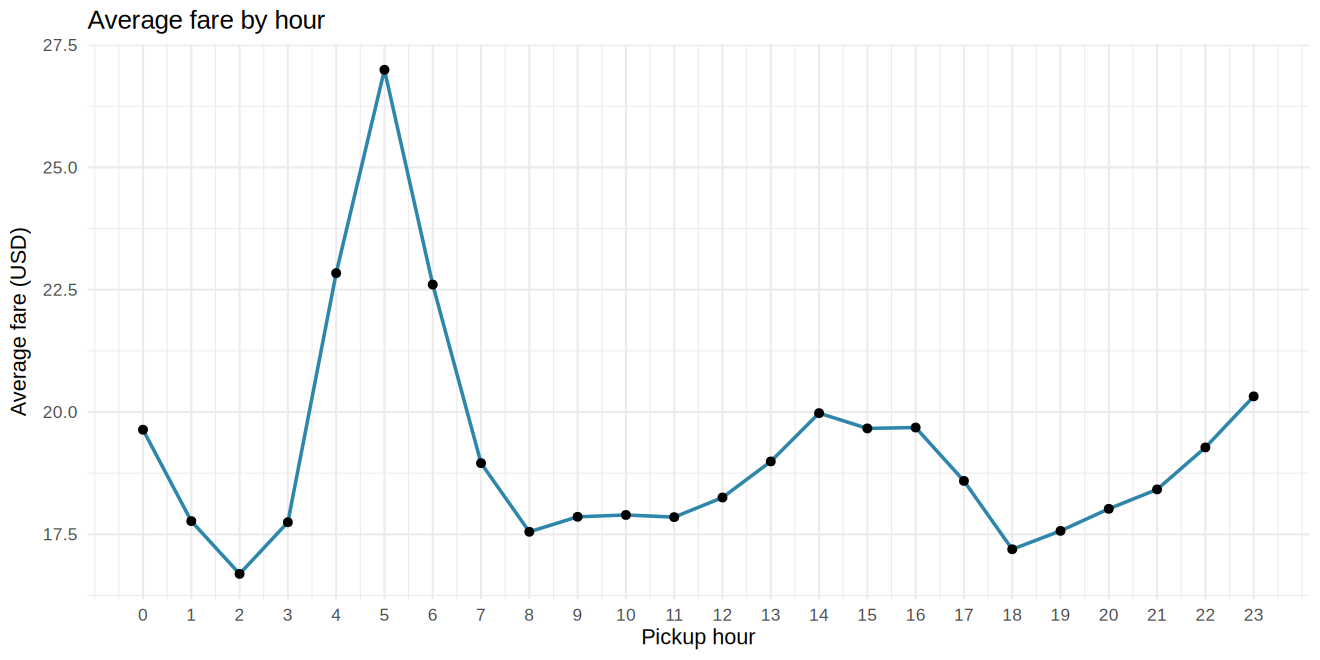

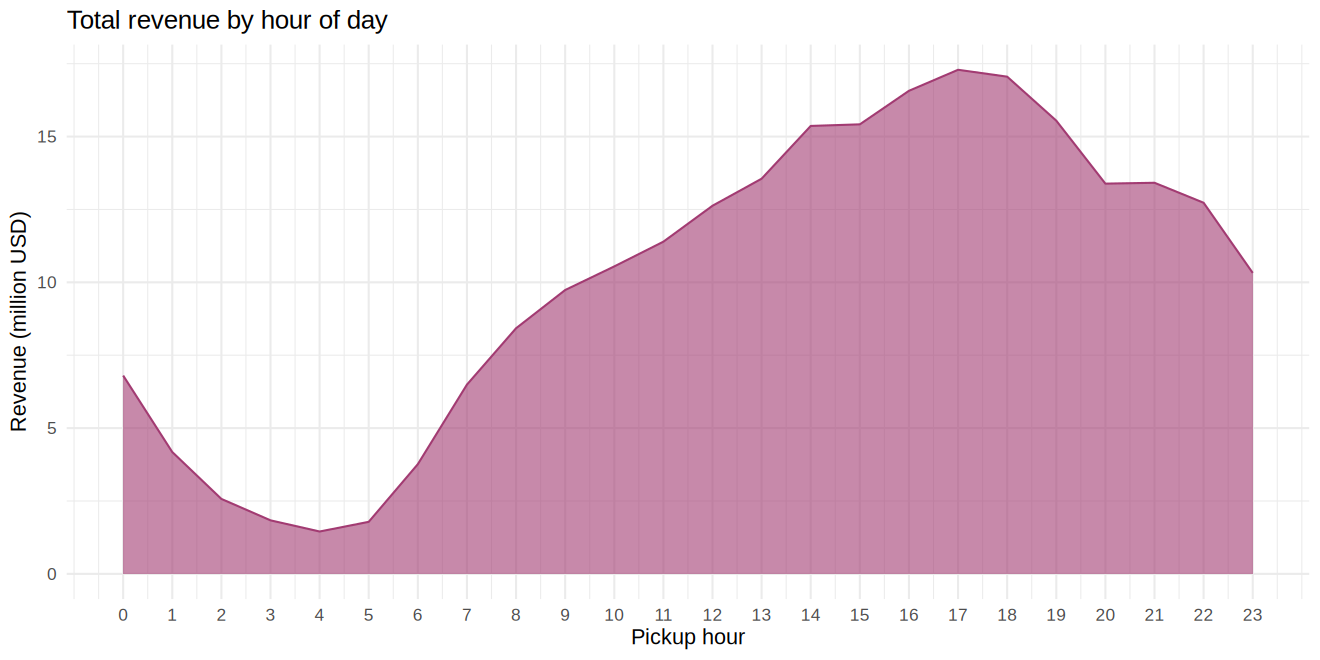

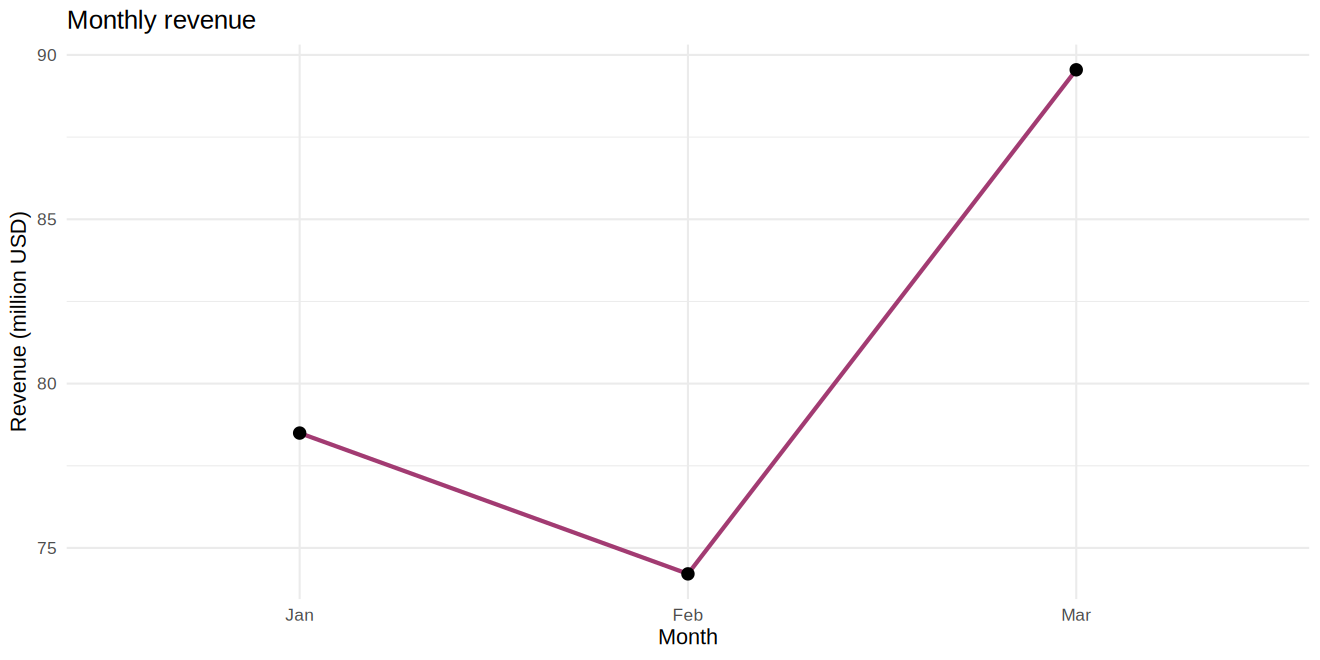

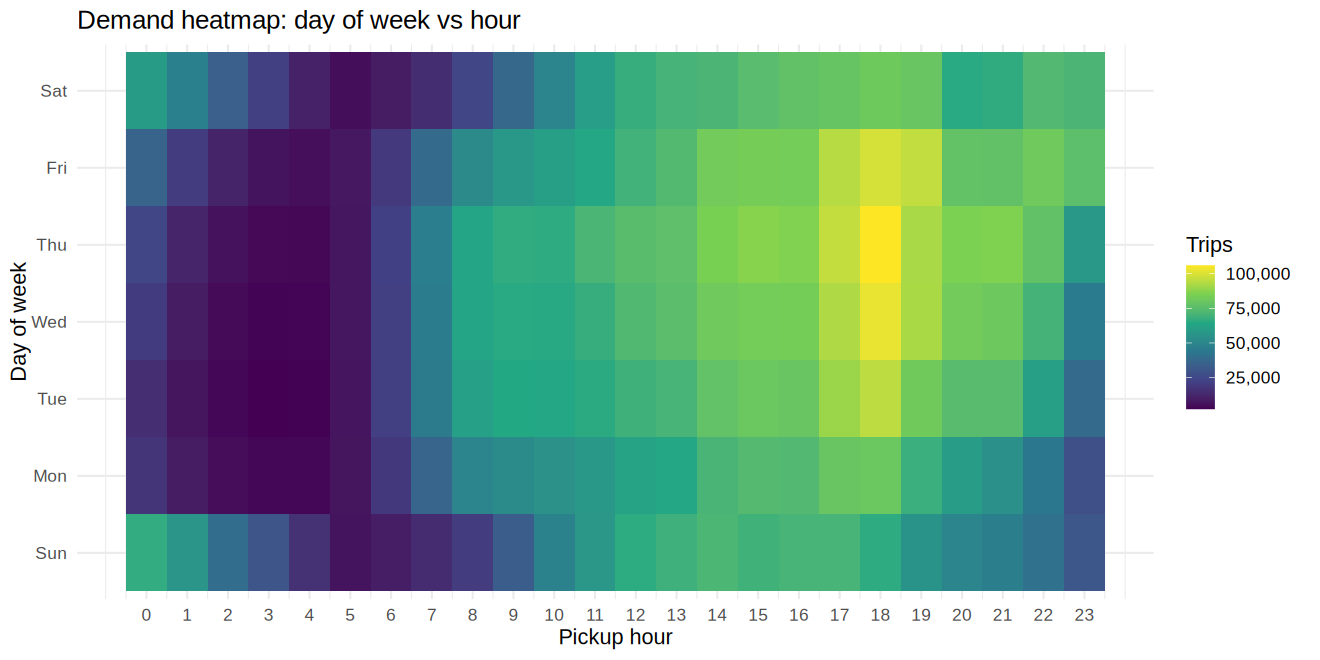

In [20]:
# 4. Average fare trend by hour
ggplot(by_hour, aes(hour, avg_fare)) + geom_line(linewidth = 1, colour = "#2E86AB") + geom_point(size = 2) +
  scale_x_continuous(breaks = 0:23) +
  labs(title = "Average fare by hour", x = "Pickup hour", y = "Average fare (USD)")

# 5. Revenue trends (by hour, and by month)
ggplot(by_hour, aes(hour, revenue / 1e6)) + geom_area(fill = "#A23B72", alpha = .6) + geom_line(colour = "#A23B72") +
  scale_x_continuous(breaks = 0:23) +
  labs(title = "Total revenue by hour of day", x = "Pickup hour", y = "Revenue (million USD)")

ggplot(by_month, aes(mon_lab(month), revenue / 1e6, group = 1)) + geom_line(linewidth = 1.2, colour = "#A23B72") + geom_point(size = 3) +
  labs(title = "Monthly revenue", x = "Month", y = "Revenue (million USD)")

# Demand heatmap: day of week x hour
ggplot(taxi[, .N, by = .(dow, hour)], aes(hour, dow, fill = N)) + geom_tile() +
  scale_fill_viridis_c(labels = comma, name = "Trips") + scale_x_continuous(breaks = 0:23) +
  labs(title = "Demand heatmap: day of week vs hour", x = "Pickup hour", y = "Day of week")

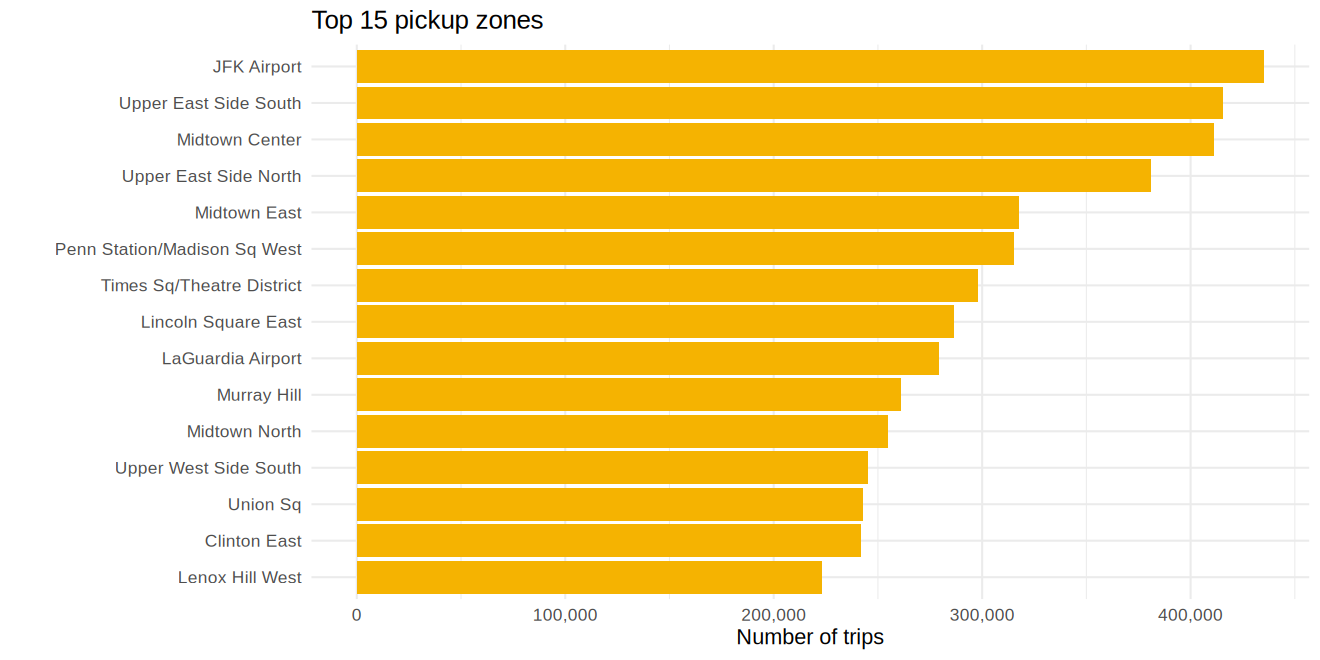

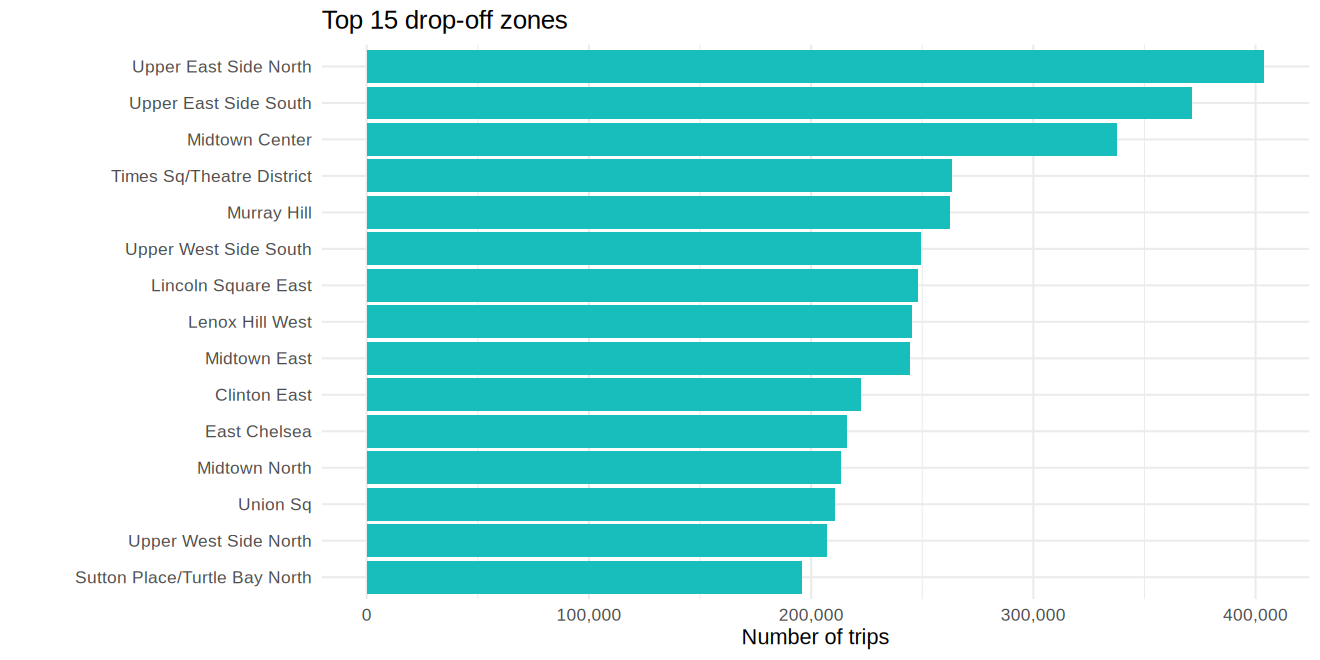

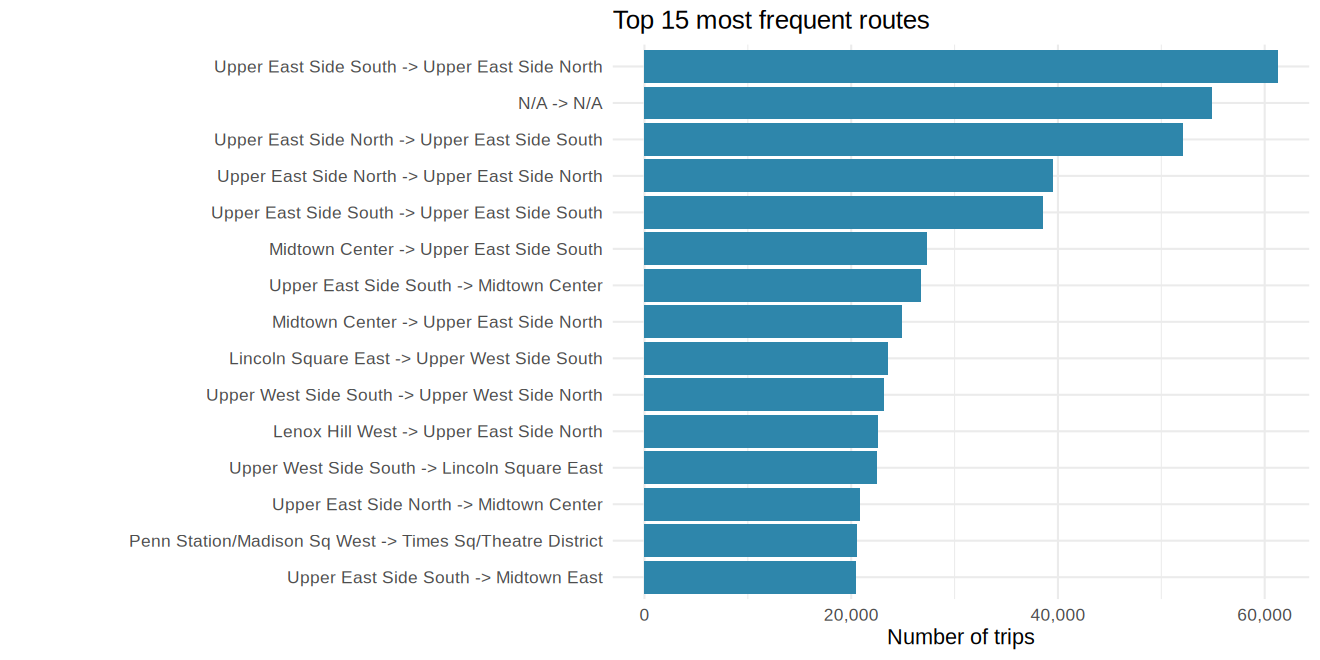

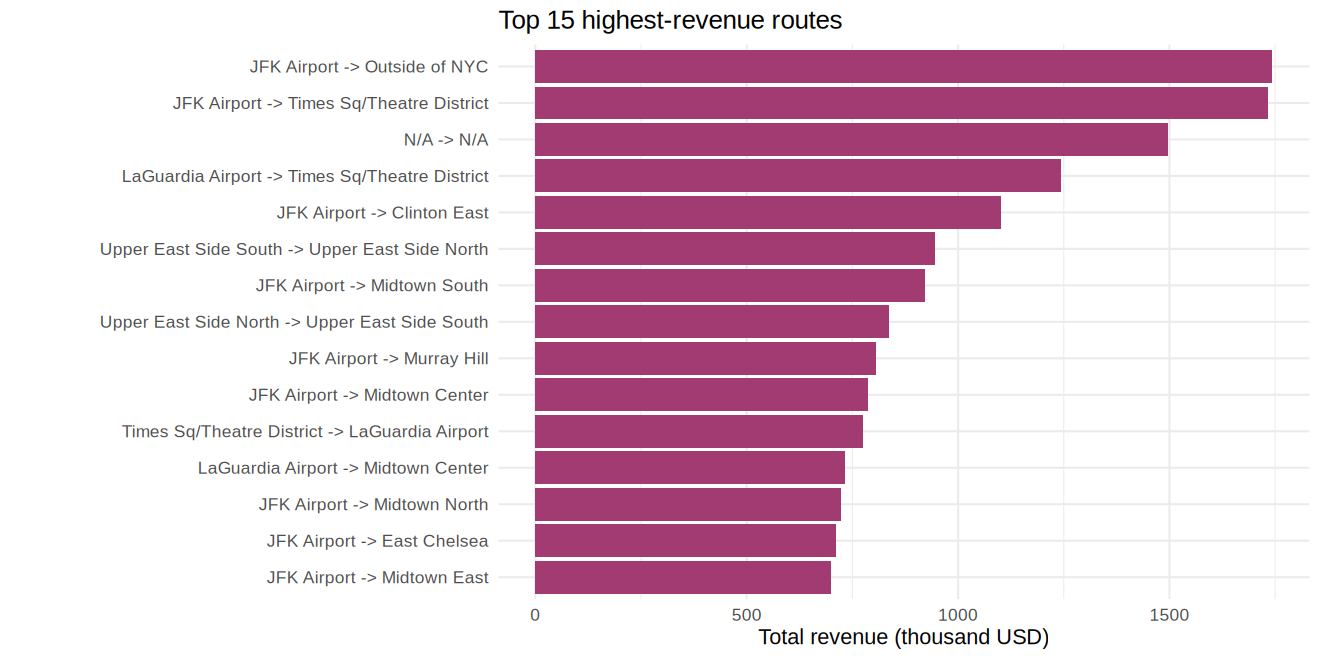

In [21]:
# 6-7. Top pickup / drop-off zones
ggplot(top_pu, aes(reorder(PU_Zone, trips), trips)) + geom_col(fill = "#F5B301") + coord_flip() +
  scale_y_continuous(labels = comma) + labs(title = "Top 15 pickup zones", x = NULL, y = "Number of trips")
ggplot(top_do, aes(reorder(DO_Zone, trips), trips)) + geom_col(fill = "#17BEBB") + coord_flip() +
  scale_y_continuous(labels = comma) + labs(title = "Top 15 drop-off zones", x = NULL, y = "Number of trips")

# 8-9. Most frequent and highest-revenue routes
ggplot(top_routes_trips, aes(reorder(route, trips), trips)) + geom_col(fill = "#2E86AB") + coord_flip() +
  scale_y_continuous(labels = comma) + labs(title = "Top 15 most frequent routes", x = NULL, y = "Number of trips")
ggplot(top_routes_rev, aes(reorder(route, revenue), revenue / 1e3)) + geom_col(fill = "#A23B72") + coord_flip() +
  labs(title = "Top 15 highest-revenue routes", x = NULL, y = "Total revenue (thousand USD)")

`geom_smooth()` using formula = 'y ~ x'


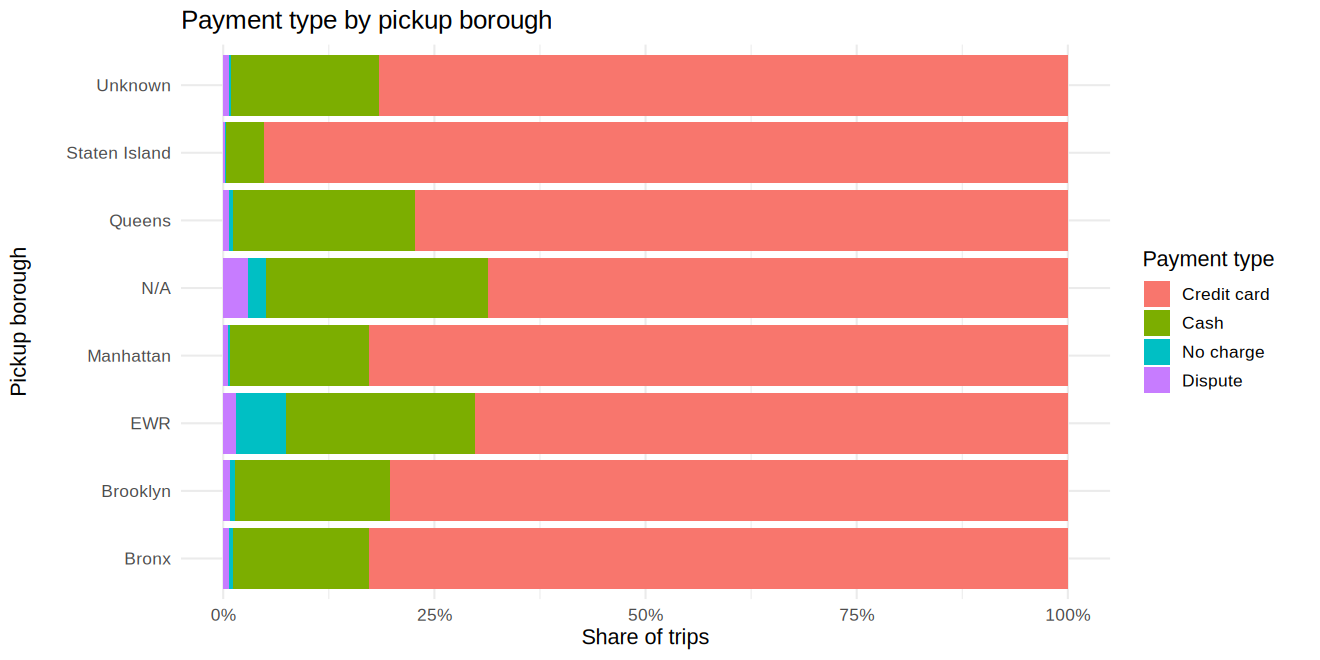

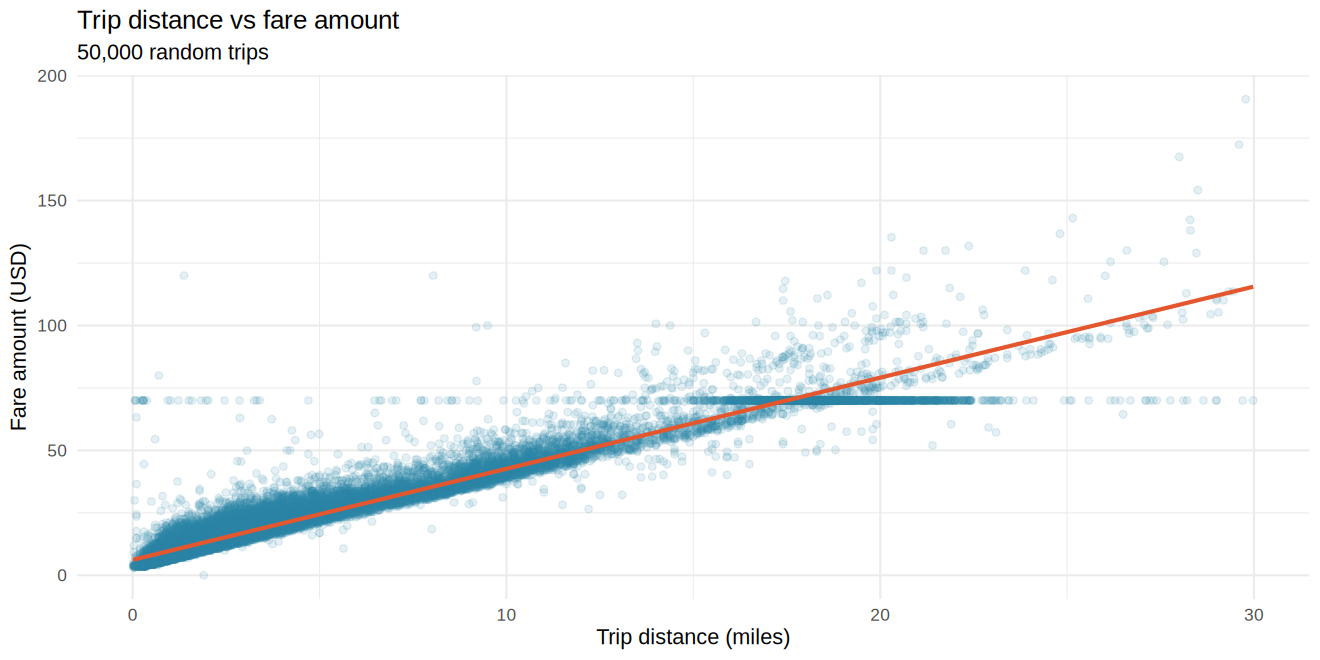

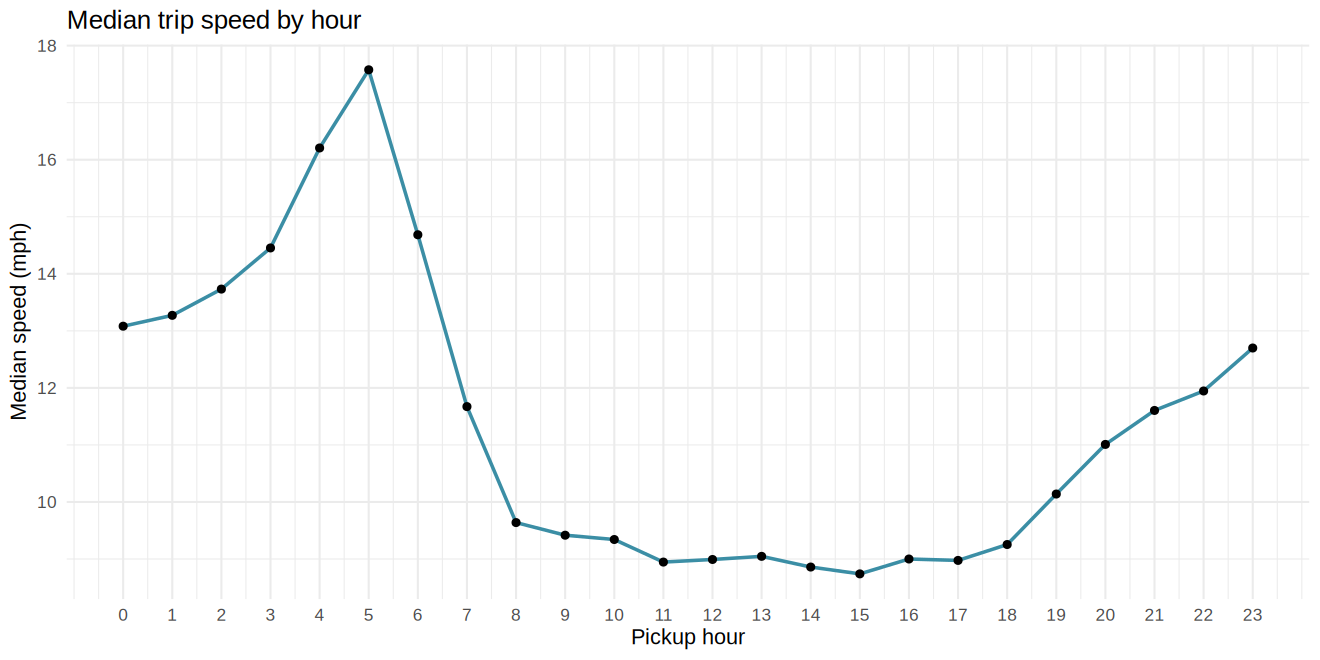

In [22]:
# 10. Payment-type distribution
ggplot(pay_borough, aes(PU_Borough, share, fill = payment_type)) + geom_col(position = "fill") +
  scale_y_continuous(labels = percent) + coord_flip() +
  labs(title = "Payment type by pickup borough", x = "Pickup borough", y = "Share of trips", fill = "Payment type")

# 11. Trip distance vs fare (50k random sample, trips <= 30 miles)
ps <- taxi[trip_distance <= 30][sample(.N, 50000)]
ggplot(ps, aes(trip_distance, fare_amount)) + geom_point(alpha = .12, colour = "#2E86AB") +
  geom_smooth(method = "lm", colour = "#E4572E", se = FALSE) +
  labs(title = "Trip distance vs fare amount", subtitle = "50,000 random trips",
       x = "Trip distance (miles)", y = "Fare amount (USD)")

# Median speed by hour (additional pattern)
ggplot(speed_hour, aes(hour, median_mph)) + geom_line(linewidth = 1, colour = "#3B8EA5") + geom_point() +
  scale_x_continuous(breaks = 0:23) +
  labs(title = "Median trip speed by hour", x = "Pickup hour", y = "Median speed (mph)")

## 10. Task 7: Critical Analysis and Recommendation
### 10.1 Evidence from your experiments (auto-generated)

In [25]:
A <- res_A; B <- res_B
dt_A <- A[approach == "data.table", median_ms]
cat("1. Fastest in Exp. A (group aggregation):", A$approach[1], sprintf("(%.1f ms)\n", A$median_ms[1]))
cat(sprintf("   data.table vs base_aggregate: %.1fx faster | vs apply_loop: %.1fx | vs purrr: %.1fx | vs lapply: %.1fx\n",
            A[approach == "base_aggregate", median_ms] / dt_A, A[approach == "apply_loop", median_ms] / dt_A,
            A[approach == "purrr_map_dbl", median_ms] / dt_A, A[approach == "lapply_split", median_ms] / dt_A))
cat("2. Fastest in Exp. B (row-wise):", B$approach[1], sprintf("(%.2f ms)", B$median_ms[1]),
    sprintf("| apply_rows is %.0fx slower than vectorized\n", B[approach == "apply_rows", median_ms] / B[approach == "vectorized", median_ms]))
cat(sprintf("3. Join: data.table %.1f ms vs base merge %.1f ms (%.1fx faster)\n",
            res_J[approach == "data.table_join", median_ms], res_J[approach == "base_merge", median_ms],
            res_J[approach == "base_merge", median_ms] / res_J[approach == "data.table_join", median_ms]))
cat(sprintf("4. Parallel (%d cores) coarse tasks: speedup %.2fx, efficiency %.0f%%\n", n_cores, exp1$speedup, 100 * exp1$efficiency))
cat(sprintf("   Parallel (%d cores) fine tasks  : speedup %.2fx, efficiency %.0f%%\n", n_cores, exp2$speedup, 100 * exp2$efficiency))
cat("5. Memory (Exp. A, MB allocated):\n"); print(A[, .(approach, mem_MB = round(mem_MB, 1))])

1. Fastest in Exp. A (group aggregation): vectorized_rowsum (425.0 ms)
   data.table vs base_aggregate: 14.4x faster | vs apply_loop: 2.9x | vs purrr: 1.1x | vs lapply: 1.2x
2. Fastest in Exp. B (row-wise): vectorized (0.47 ms) | apply_rows is 888x slower than vectorized
3. Join: data.table 84.2 ms vs base merge 2644.2 ms (31.4x faster)
4. Parallel (2 cores) coarse tasks: speedup 1.11x, efficiency 55%
   Parallel (2 cores) fine tasks  : speedup 1.17x, efficiency 59%
5. Memory (Exp. A, MB allocated):
            approach mem_MB
              <char>  <num>
1: vectorized_rowsum  239.5
2:        data.table  258.2
3:     purrr_map_dbl  309.7
4:      lapply_split  309.7
5:       base_tapply  379.8
6:        apply_loop 1789.4
7:    base_aggregate 2103.5
